In [2]:
## Step 1:Load and Explore the dataset
# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df= pd.read_csv("SuperStoreOrders.csv")

df.head(10)

# Check dataset shape,column names,and data types
df.info()

# Convert order_date and ship_date into datetime format

df['order_date']= pd.to_datetime(df['order_date'], format='mixed')
df['ship_date']= pd.to_datetime(df['ship_date'], format='mixed') 
print(df.dtypes)
df['order_date'].isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  str    
 1   order_date      51290 non-null  str    
 2   ship_date       51290 non-null  str    
 3   ship_mode       51290 non-null  str    
 4   customer_name   51290 non-null  str    
 5   segment         51290 non-null  str    
 6   state           51290 non-null  str    
 7   country         51290 non-null  str    
 8   market          51290 non-null  str    
 9   region          51290 non-null  str    
 10  product_id      51290 non-null  str    
 11  category        51290 non-null  str    
 12  sub_category    51290 non-null  str    
 13  product_name    51290 non-null  str    
 14  sales           51290 non-null  str    
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null  float64
 1

np.int64(0)

In [4]:
# # Step 2: Basic Data Cleaning
print(df['sales'].dtype)
df['sales'].isnull().sum()

# Check Category 
print (df.dtypes)
df['sales']= df['sales'].astype(str)
df['sales']= df['sales'].str.replace(',','',regex=False)

# Convert the strings to numeric
df['sales']= pd.to_numeric(df['sales'])
print(df['sales'].nlargest(5))
total_sales=df['sales'].sum()
print ("Total Sales:",total_sales)

str
order_id                     str
order_date        datetime64[us]
ship_date         datetime64[us]
ship_mode                    str
customer_name                str
segment                      str
state                        str
country                      str
market                       str
region                       str
product_id                   str
category                     str
sub_category                 str
product_name                 str
sales                        str
quantity                   int64
discount                 float64
profit                   float64
shipping_cost            float64
order_priority               str
year                       int64
dtype: object
1103     22638
29530    17500
36239    14000
46525    11200
48097    10500
Name: sales, dtype: int64
Total Sales: 12642905


In [5]:
# Step 3: Discriptive Statistics
total_sales=df['sales'].sum()
total_profit=df['profit'].sum()
average_discount=df['discount'].mean()

print("Total sales:",total_sales)
print("Total profit:",total_profit)
print("Average discount:",average_discount)

print("Min:",df['sales'].min())
print("Max:",df['sales'].max())
print("Mean",df['sales'].mean())
print("Median",df['sales'].median())

print("Min",df['profit'].min())
print("Max",df['profit'].max())
print("Mean",df['profit'].mean())
print("Median",df['profit'].median())

# Identify top 10 products by sales
df.groupby('product_name')['sales'].sum().nlargest(10)
# Identify top 10 products by profit
df.groupby('product_name')['profit'].sum().nlargest(10)


Total sales: 12642905
Total profit: 1469034.82128
Average discount: 0.14290754533047378
Min: 0
Max: 22638
Mean 246.49844024176252
Median 85.0
Min -6599.978
Max 8399.976
Mean 28.641739545330474
Median 9.24


product_name
Canon imageCLASS 2200 Advanced Copier                       25199.9280
Cisco Smart Phone, Full Size                                17238.5206
Motorola Smart Phone, Full Size                             17027.1130
Hoover Stove, Red                                           11807.9690
Sauder Classic Bookcase, Traditional                        10672.0730
Harbour Creations Executive Leather Armchair, Adjustable    10427.3260
Nokia Smart Phone, Full Size                                 9938.1955
Cisco Smart Phone, with Caller ID                            9786.6408
Nokia Smart Phone, with Caller ID                            9465.3257
Belkin Router, USB                                           8955.0180
Name: profit, dtype: float64

In [6]:
# # Step 4: Regional and Category Analysis
region_summary=df.groupby('region')[['sales','profit']].sum()
print(region_summary)

df["profit_margin"]= df['profit']/df['sales']
category_summary=df.groupby('category')['profit_margin'].mean()
print(category_summary)

subcategory_summary=df.groupby('sub_category')[['sales','profit']].sum().sort_values(by='profit',ascending=False)
print(subcategory_summary)
# Average Profit margin
subcategory_margin=df.groupby('sub_category')['profit_margin'].mean().sort_values(ascending=False)
print(subcategory_margin)
print(subcategory_margin.head(5))
print(subcategory_margin.tail(5))


                  sales        profit
region                               
Africa           783776   88871.63100
Canada            66932   17817.39000
Caribbean        324281   34571.32104
Central         2822399  311403.98164
Central Asia     752839  132480.18700
EMEA             806184   43897.97100
East             678834   91522.78000
North           1248192  194597.95252
North Asia       848349  165578.42100
Oceania         1100207  121666.64200
South           1600960  140355.76618
Southeast Asia   884438   17852.32900
West             725514  108418.44890
category
Furniture          0.008748
Office Supplies        -inf
Technology         0.049658
Name: profit_margin, dtype: float64
                sales        profit
sub_category                       
Copiers       1509439  258567.54818
Phones        1706874  216717.00580
Bookcases     1466559  161924.41950
Chairs        1501682  141973.79750
Appliances    1011081  141680.58940
Accessories    749307  129626.30620
Storage      

In [7]:
# # Step 5: Customer Segmentation
df.groupby('segment')[['sales','profit']].agg(['mean','sum'])

# Top 10 Customers by sale
df.groupby('customer_name')['sales'].sum().nlargest(10)

customer_name
Tom Ashbrook          40489
Tamara Chand          37453
Greg Tran             35552
Christopher Conant    35187
Sean Miller           35170
Bart Watters          32315
Natalie Fritzler      31778
Fred Hopkins          30404
Jane Waco             30288
Hunter Lopez          30246
Name: sales, dtype: int64

In [19]:
# # # Step 6: Time Series Analysis
# Compare yearly sales growth
yearly_sales= df.groupby('year')['sales'].sum()
yearly_growth= yearly_sales.pct_change()* 100
print("Yearly Sales:")
print(yearly_sales)
print("\nYearly Growth (%):")
print(yearly_growth)

# Convert Ship_date into date_time
df['ship_date']= pd.to_datetime(df['ship_date'], errors='coerce')
df['order_date']= pd.to_datetime(df['order_date'], errors='coerce')
df['shipping_time']= (df['ship_date']-df['order_date']).dt.days
print ("Shipping Time Statistics")
print (df['shipping_time'].describe())


Yearly Sales:
year
2011    2259511
2012    2677493
2013    3405860
2014    4300041
Name: sales, dtype: int64

Yearly Growth (%):
year
2011          NaN
2012    18.498781
2013    27.203320
2014    26.254191
Name: sales, dtype: float64


KeyError: 'order_date'

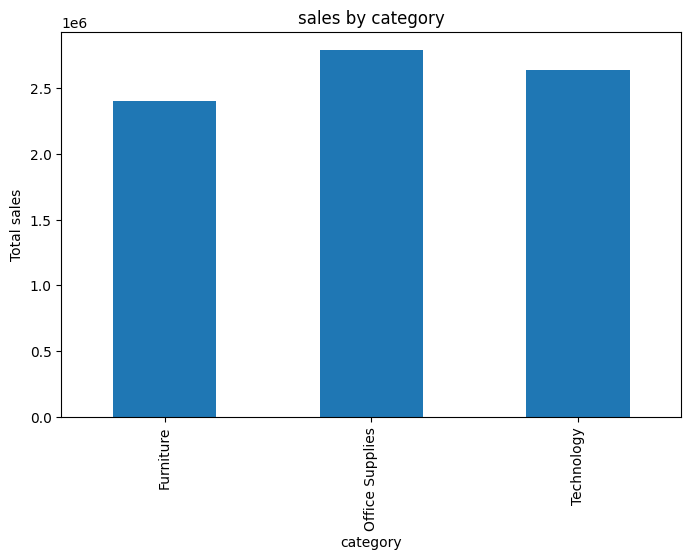

In [91]:
# # Step 7: Visualizations
df['sales']= pd.to_numeric(df['sales'],errors='coerce')
# Group sales by category
category_sales= df.groupby('category')['sales'].sum()

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')
plt.title("sales by category")
plt.xlabel("category")
plt.ylabel("Total sales")
plt.show()

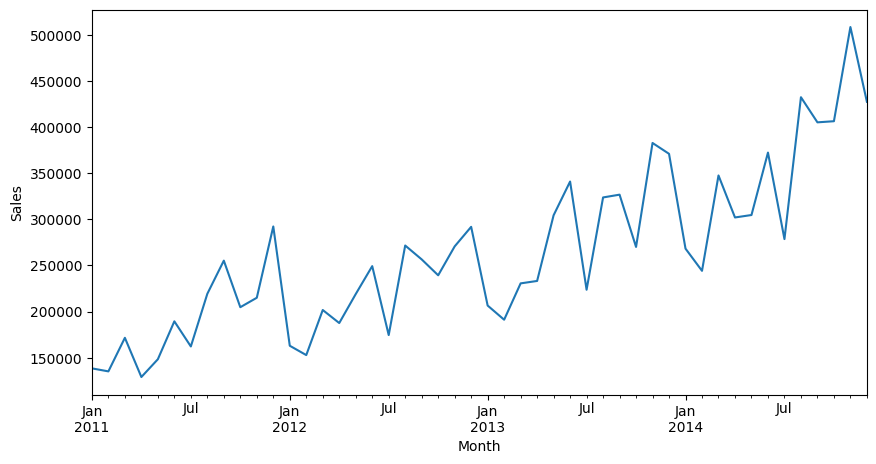

In [53]:
# # Line Chart: Monthly Sales Trend
# Setting index
monthly_sales= df['sales'].resample('ME').sum()

plt.figure(figsize=(10,5))
monthly_sales.plot()
# plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

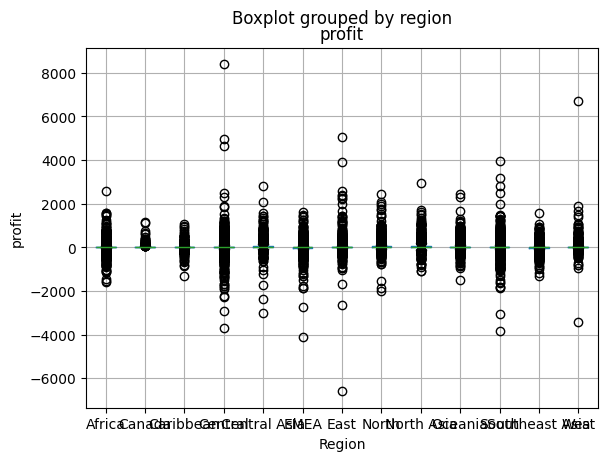

In [12]:
df.boxplot(column='profit',by='region')
plt.title=('profit Distribution by region')
plt.xlabel('Region')
plt.ylabel('profit')
plt.show()

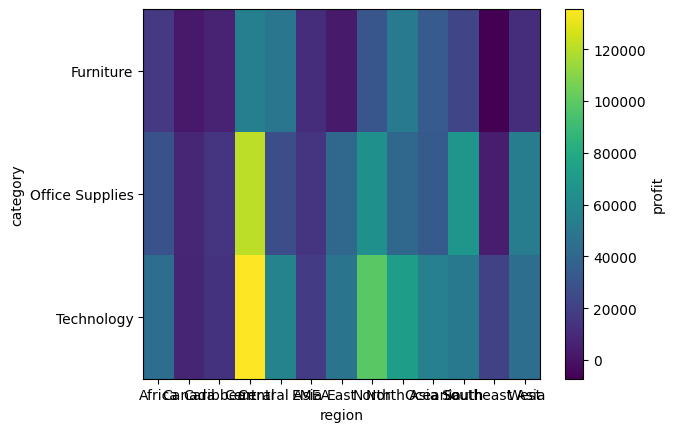

In [20]:
pivot_table=df.pivot_table(
    values='profit',
    index='category',
    columns='region',
    aggfunc='sum'
)
plt.figure()
plt.imshow(pivot_table,aspect='auto')
plt.colorbar(label='profit')
plt.xticks(np.arange(len(pivot_table.columns)),pivot_table.columns)
plt.yticks(np.arange(len(pivot_table.index)),pivot_table.index)

plt.xlabel('region')
plt.ylabel('category')
plt.show()